<a href="https://colab.research.google.com/github/SantiaGaGo/Financiero---UniAndes-TodosALaU/blob/main/1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.5. Personas llegan a un paradero de bus a la tasa de uno cada 20 +- 15 segundos. Ellos esperan por el bus a menos que la cola ya tenga 10 personas, en cuyo caso se van. Un bus llega cada 5 +- 1 minutos. Las personas esperan abordar el bus, uno a la vez, tomando 5 segundos cada uno. El bus espera por lo menos 20 segundos, de lo contrario sale tan pronto como las personas dejen de abordar. Simular 10 cargas del bus de personas (Utilice flujos de transacciones separadas para representar las personas y los buses y de una mayor prioridad a las personas. Use un suich lógico para representar la presencia o ausencia de un bus)

**1. Nuestros parámetros del Sistema**

​     Llegada de Personas: 20 ± 15 segundos.

​     Llegada del Bus: 300 ± 60 segundos ( 5 ± 1 minutos a segundos).

​     Tiempo de Abordaje: 5 segundos FIJOS por persona.

​     Condición de Término: La simulación termina exactamente después de procesar 10 llegadas y salidas de buses.


​**2. La Lógica de Control Abandono (Balking):**

    Capacidad máxima de la cola = 10. Si llega una persona y hay 10 esperando, esa entidad se destruye (ESE CLIENTE SE PIERDE).

​     Suich Lógico:Estado ON = bus presente, las personas avanzan. Estado OFF = bus ausente, las personas se acumulan en la cola.

​     Prioridad (MANEJO DE LA SIMULTANEIDAD): Si un bus y una persona se generan en el mismo milisegundo exacto, la persona entra primero. SI NO FUESE ASI, el bus vería la parada vacía, iniciaría su cronómetro y la persona quedaría esperando al siguiente bus por un error de Nuestro Modelo De simulación.



​**3. Regla de Salida del Bus (EL CUELLO DE BOTELLA Identificado)**

​     La condición de estar un mínimo de 20 segundos genera 3 escenarios operativos:

​     Menos de 4 personas en cola: Tardan menos de 20s en subir. El bus se queda estacionado HASTA completar exactamente los 20 segundos.

​     Exactamente 4 personas: Tardan 20s (4 x 5s). El bus arranca de forma inmediata al subir el último.

​     De 5 a 10 personas en cola: Tardan entre 25s y 50s. La regla de los 20 segundos ya se sobrepasó, así que el bus arranca en el instante en que el último pasajero termina de abordar.

In [ ]:
#Modelo basado en SymPy so
!pip install simpy -q

import simpy
import random
import pandas as pd
from IPython.display import display, HTML


In [ ]:
#PARÁMETROS DEL SISTEMA
T_LLEGADA_P_MIN, T_LLEGADA_P_MAX = 5, 35
# 20 ± 15 segundos
T_LLEGADA_B_MIN, T_LLEGADA_B_MAX = 240, 360
# 5 ± 1 minutos (* 60 para darlo en segundos)
T_ABORDAJE = 5
# Segundos por persona nos lo da el ejercicio
T_MIN_ESPERA_BUS = 20
# Segundos mínimos que espera el bus acorde al ejercicio
CAPACIDAD_COLA = 10
# Máximo de personas esperando
MAX_BUSES = 10
# Condición de parada

class Paradero:
    def __init__(self, env):
        self.env = env
        self.cola_espera = 0

        # Recurso: Representa la puerta del bus (para que se suba 1 sola persona a la vez)
        self.puerta_bus = simpy.Resource(env, capacity=1)

        # EL Suich Lógico que nos indica si el bus está con puertas abiertas para subirse
        self.bus_presente = env.event()

        # Evento interno para avisar al bus estacionado que llegó alguien nuevo
        self.nueva_persona = env.event()

        # Recolección de datos
        self.buses_despachados = 0
        self.total_personas_llegaron = 0
        self.total_personas_perdidas = 0
        self.total_personas_abordaron = 0
        self.bitacora = []

    def log(self, mensaje):
        """Guarda los eventos para el DataFrame final"""
        self.bitacora.append({"Tiempo (s)": round(self.env.now, 1), "Evento": mensaje})

In [ ]:
## DIsenio de la logica detras de las personas y los buses
def persona(env, id_persona, paradero):
    paradero.total_personas_llegaron += 1

    #Decision de Abandono
    if paradero.cola_espera < CAPACIDAD_COLA:
        paradero.cola_espera += 1
        paradero.log(f"{id_persona} llega. Cola: {paradero.cola_espera}/10")

        # Si el bus estaba esperandola, le avisamos que llegó alguien
        if not paradero.nueva_persona.triggered:
            paradero.nueva_persona.succeed()

        # Esperar alSuich Lógico osea Solo avanzar si el bus está presente
        yield paradero.bus_presente

        #Proceso de abordaje uno x uno
        with paradero.puerta_bus.request() as req:
            yield req
            yield env.timeout(T_ABORDAJE)

            paradero.cola_espera -= 1
            paradero.total_personas_abordaron += 1
            paradero.log(f"{id_persona} aborda. Cola restante: {paradero.cola_espera}")
    else:
        # La fila está llena y abandonan
        paradero.total_personas_perdidas += 1
        paradero.log(f"{id_persona} se va por cola llena (ABANDONO).")

def bus(env, id_bus, paradero):
    # PRIORIDAD: El bus cede 1 microsegundo. Si un bus y una persona llegan
    # en el mismo instante, esto nos garantiza que la persona entre a la fila primero.
    yield env.timeout(0.00001)

    t_llegada = env.now
    paradero.log(f"*** LLEGA BUS {id_bus} ***")

    # Activar Suich Lógico (Las personas empiezan a pedir la puerta)
    paradero.bus_presente.succeed()

    ###Lógica de espera y salida del bus
    while True:
        t_transcurrido = env.now - t_llegada

        ## Condición para irse: No hay gente en cola, nadie está en la puerta, y pasaron los 20segs
        if paradero.cola_espera == 0 and paradero.puerta_bus.count == 0:
            if t_transcurrido >= T_MIN_ESPERA_BUS:
                break # Se va el bus
            else:
                # Faltan segundos.... Espera hasta que pasen los 20segs. O llegue alguien nuevo.
                t_restante = T_MIN_ESPERA_BUS - t_transcurrido
                yield paradero.nueva_persona | env.timeout(t_restante)
                paradero.nueva_persona = env.event() # Reseteo
        else:
            # Hay gente abordando o en la fila. El bus espera pacientemente el abordaje.
            yield env.timeout(T_ABORDAJE)

    # Apagar Suich Lógico osea se cierra la puerta y el evento se reinicia
    paradero.bus_presente = env.event()
    paradero.buses_despachados += 1
    paradero.log(f"*** SALE BUS {id_bus} (Tiempo en parada: {round(env.now - t_llegada, 1)}s) ***")

In [ ]:
def generador_personas(env, paradero):
    i = 1
    while paradero.buses_despachados < MAX_BUSES or paradero.cola_espera > 0:
       # Así espera a que se vacíe la fila antes de dejar de generar personas
        yield env.timeout(random.uniform(T_LLEGADA_P_MIN, T_LLEGADA_P_MAX))
        env.process(persona(env, f"Persona {i}", paradero))
        i += 1

def generador_buses(env, paradero):
    j = 1
    while j <= MAX_BUSES:
        yield env.timeout(random.uniform(T_LLEGADA_B_MIN, T_LLEGADA_B_MAX))
        yield env.process(bus(env, j, paradero)) ###para detiener el generador hasta que el bus se va
        j += 1

###PARA EJECUCIÓN
#Semilla x reproducibilidad de la simulación
random.seed(42)
env = simpy.Environment()
sistema_paradero = Paradero(env)

env.process(generador_personas(env, sistema_paradero))
env.process(generador_buses(env, sistema_paradero))

env.run() # Corre

In [ ]:
#Nuestro dataframe para la visualizacion de resultadios
df_log = pd.DataFrame(sistema_paradero.bitacora)

### Imprimir un Resumen
print("-"*40)
print("RESULTADOS DE LA SIMULACIÓN")
print("="*40)
print(f"Total Buses  : {sistema_paradero.buses_despachados}")
print(f"Total Personas que Llegaron : {sistema_paradero.total_personas_llegaron}")
print(f"Total Abordajes         : {sistema_paradero.total_personas_abordaron}")
print(f"Personas Perdidas       : {sistema_paradero.total_personas_perdidas}")
print(f"Tasa de Pérdida         : {(sistema_paradero.total_personas_perdidas / sistema_paradero.total_personas_llegaron) * 100:.2f}%")
print("="*40)
print(f"Tiempo total simulado   : {round(env.now, 1)} segundos")
print(f"Tiempo total simulado   : {round(env.now, 1)/60} minutos")
print("="*40)
# Mostrar los primeros 15 y últimos quince eventos
display(df_log.head(15))
display(df_log.tail(15))

----------------------------------------
 RESULTADOS DE LA SIMULACIÓN
Total Buses  : 10
Total Personas que Llegaron : 187
Total Abordajes         : 130
Personas Perdidas       : 56
Tasa de Pérdida         : 29.95%
Tiempo total simulado   : 3649.7 segundos
Tiempo total simulado   : 60.82833333333333 minutos


,Tiempo (s),Evento
0,24.2,Persona 1 llega. Cola: 1/10
1,37.4,Persona 2 llega. Cola: 2/10
2,49.1,Persona 3 llega. Cola: 3/10
3,76.2,Persona 4 llega. Cola: 4/10
4,101.5,Persona 5 llega. Cola: 5/10
5,133.3,Persona 6 llega. Cola: 6/10
6,140.9,Persona 7 llega. Cola: 7/10
7,158.6,Persona 8 llega. Cola: 8/10
8,164.5,Persona 9 llega. Cola: 9/10
9,176.0,Persona 10 llega. Cola: 10/10


,Tiempo (s),Evento
322,3581.2,Persona 167 aborda. Cola restante: 8
323,3586.2,Persona 168 aborda. Cola restante: 7
324,3591.2,Persona 169 aborda. Cola restante: 6
325,3596.2,Persona 170 aborda. Cola restante: 5
326,3597.4,Persona 185 llega. Cola: 6/10
327,3601.2,Persona 171 aborda. Cola restante: 5
328,3606.2,Persona 172 aborda. Cola restante: 4
329,3611.2,Persona 173 aborda. Cola restante: 3
330,3616.2,Persona 174 aborda. Cola restante: 2
331,3621.2,Persona 184 aborda. Cola restante: 1


In [ ]:
# PARA ESTADISTICAS DEL MODELOO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [ ]:
#ESTADÍSTICAS x BUS

# usando bitácora cuántas personas subió cada bus
estadisticas_bus = {}
bus_actual = None

for evento in sistema_paradero.bitacora:
    msg = evento["Evento"]
    t   = evento["Tiempo (s)"]

    if msg.startswith("*** LLEGA BUS"):
        bus_actual = msg.split("LLEGA ")[1].split(" ***")[0]
        estadisticas_bus[bus_actual] = {
            "llegada": t,
            "salida": None,
            "pasajeros": 0,
            "tiempo_en_parada": None
        }
    elif "aborda" in msg and bus_actual:
        estadisticas_bus[bus_actual]["pasajeros"] += 1
    elif msg.startswith("*** SALE BUS"):
        nombre_bus = msg.split("SALE ")[1].split(" (")[0]
        if nombre_bus in estadisticas_bus:
            estadisticas_bus[nombre_bus]["salida"] = t
            estadisticas_bus[nombre_bus]["tiempo_en_parada"] = round(
                t - estadisticas_bus[nombre_bus]["llegada"], 1
            )

print("=" * 65)
print("       ESTADÍSTICAS POR BUS")
print("=" * 65)
print(f"{'Bus':<10} {'Llegada(segs)':<13} {'Salida(segs)':<12} {'Pasajeros':<11} {'En parada(segs)'}")
print("-" * 65)
for nombre, d in estadisticas_bus.items():
    print(f"{nombre:<10} {d['llegada']:<13} {d['salida']:<12} {d['pasajeros']:<11} {d['tiempo_en_parada']}")
print("-" * 65)
pasajeros_lista = [d["pasajeros"] for d in estadisticas_bus.values()]
print(f"{'Promedio':<35} {np.mean(pasajeros_lista):.1f}")
print(f"{'Máximo':<35} {max(pasajeros_lista)}")
print(f"{'Mínimo':<35} {min(pasajeros_lista)}")
print("=" * 65)


       ESTADÍSTICAS POR BUS
Bus        Llegada(segs) Salida(segs) Pasajeros   En parada(segs)
-----------------------------------------------------------------
BUS 1      243.0         313.0        13          70.0
BUS 2      553.8         618.8        12          65.0
BUS 3      904.2         979.2        14          75.0
BUS 4      1292.3        1357.3       12          65.0
BUS 5      1676.0        1751.0       14          75.0
BUS 6      2054.4        2129.4       14          75.0
BUS 7      2473.9        2543.9       13          70.0
BUS 8      2792.2        2862.2       13          70.0
BUS 9      3164.3        3229.3       12          65.0
BUS 10     3566.2        3636.2       13          70.0
-----------------------------------------------------------------
Promedio                            13.0
Máximo                              14
Mínimo                              12


In [ ]:
###TIEMPO PROMEDIO DE ESPERA POR PERSONA
#
# Registramos t_llegada y t_abordaje por persona desde la bitácora
tiempos_llegada  = {}
tiempos_abordaje = {}

for evento in sistema_paradero.bitacora:
    msg = evento["Evento"]
    t   = evento["Tiempo (s)"]

    # "Persona X llega. FILA: ..."
    if "llega. Cola:" in msg:
        nombre = msg.split(" llega")[0]
        tiempos_llegada[nombre] = t

    # "Persona X aborda. fila restante: ..."
    elif "aborda. Cola" in msg:
        nombre = msg.split(" aborda")[0]
        tiempos_abordaje[nombre] = t

esperas = []
for nombre in tiempos_abordaje:
    if nombre in tiempos_llegada:
        espera = tiempos_abordaje[nombre] - tiempos_llegada[nombre]
        esperas.append(espera)

print()
print("=" * 45)
print("TIEMPO DE ESPERA POR PERSONA")
print("=" * 45)
print(f"Personas con dato de espera : {len(esperas)}")
print(f"Espera promedio             : {np.mean(esperas):.1f} s  ({np.mean(esperas)/60:.2f} min)")
print(f"Espera máxima               : {max(esperas):.1f} s  ({max(esperas)/60:.2f} min)")
print(f"Espera mínima               : {min(esperas):.1f} s  ({min(esperas)/60:.2f} min)")
print(f"Desviación estándar         : {np.std(esperas):.1f} s")
print("=" * 45)



   TIEMPO DE ESPERA POR PERSONA
Personas con dato de espera : 130
Espera promedio             : 175.2 s  (2.92 min)
Espera máxima               : 340.9 s  (5.68 min)
Espera mínima               : 5.0 s  (0.08 min)
Desviación estándar         : 98.3 s


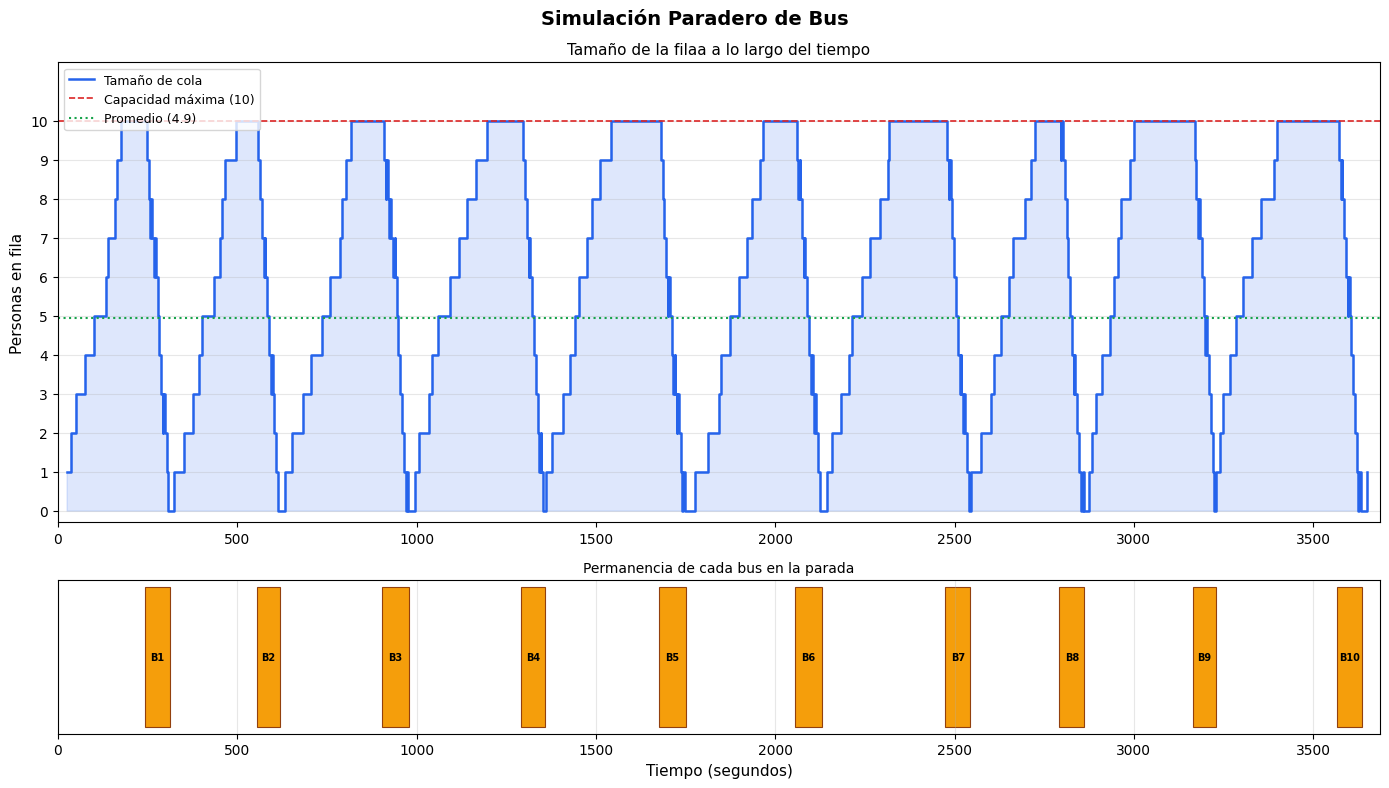

In [ ]:
# GRÁFICAMOS TAMAÑO DE LA FILA EN EL TIEMPO
tiempos_cola = []
tamaños_cola = []
llegadas_bus = []
salidas_bus  = []

cola_actual = 0
for evento in sistema_paradero.bitacora:
    msg = evento["Evento"]
    t   = evento["Tiempo (s)"]

    if "llega. Cola:" in msg:
        cola_actual = int(msg.split("Cola: ")[1].split("/")[0])
        tiempos_cola.append(t)
        tamaños_cola.append(cola_actual)
    elif "aborda. Cola restante:" in msg:
        cola_actual = int(msg.split("Cola restante: ")[1])
        tiempos_cola.append(t)
        tamaños_cola.append(cola_actual)
    elif "LLEGA BUS" in msg:
        llegadas_bus.append(t)
    elif "SALE BUS" in msg:
        salidas_bus.append(t)

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                         gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("Simulación Paradero de Bus", fontsize=14, fontweight="bold")

##fila con el tiempo
ax = axes[0]
ax.step(tiempos_cola, tamaños_cola, where="post",
        color="#2563EB", linewidth=1.8, label="Tamaño de cola")
ax.fill_between(tiempos_cola, tamaños_cola, step="post",
                alpha=0.15, color="#2563EB")

# Línea de capacidad máxima
ax.axhline(y=CAPACIDAD_COLA, color="#DC2626", linestyle="--",
           linewidth=1.2, label="Capacidad máxima (10)")

# ##Promedio
ax.axhline(y=np.mean(tamaños_cola), color="#16A34A", linestyle=":",
           linewidth=1.5, label=f"Promedio ({np.mean(tamaños_cola):.1f})")

ax.set_ylabel("Personas en fila", fontsize=11)
ax.set_xlim(0, max(tiempos_cola) * 1.01)
ax.set_ylim(-0.3, CAPACIDAD_COLA + 1.5)
ax.set_yticks(range(0, CAPACIDAD_COLA + 1))
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_title("Tamaño de la filaa a lo largo del tiempo", fontsize=11)

# linea tiempo busess
ax2 = axes[1]
for i, (ll, sl) in enumerate(zip(llegadas_bus, salidas_bus)):
    ax2.barh(0, sl - ll, left=ll, height=0.5,
             color="#F59E0B", edgecolor="#92400E", linewidth=0.8)
    ax2.text((ll + sl) / 2, 0, f"B{i+1}",
             ha="center", va="center", fontsize=7, fontweight="bold")

ax2.set_xlim(0, max(tiempos_cola) * 1.01)
ax2.set_yticks([])
ax2.set_xlabel("Tiempo (segundos)", fontsize=11)
ax2.set_title("Permanencia de cada bus en la parada", fontsize=10)
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("simulacion_paradero.png", dpi=150, bbox_inches="tight")
plt.show()
